In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.7
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)

session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abb

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.656 s
Baseline,off


Not setting metadata
576 matching events found
No baseline correction applied
0 projection items activated
combining channels using "gfp"


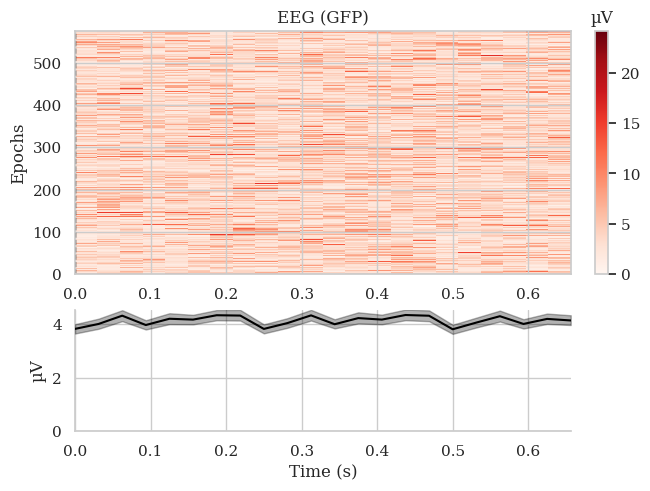

[<Figure size 640x480 with 3 Axes>]

In [4]:
epochs.plot_image()

In [5]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [6]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_2584/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 22)

In [123]:
from hoda.hoda import HODA, f_multiway,trunc_eigh
from hoda.cov import ledoit_wolf_shrinkage, oas, mode_scatter
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import combine_pvalues
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
    rank=2,
    max_iter=256,
    tol=1e-12,
    init ='svd',
    shrinkage='lw',
    toeplitz=None,
    obj='rt',
    solver='lanczos',
    taper=True,
    keep_train_info=True,
    verbose=True,
)


hoda.fit(X,y)
hoda

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...


HODA(keep_train_info=True, rank=2, taper=True, tol=1e-12, verbose=True)

In [124]:
hoda.train_info_

,F_tr,F_rt,mse,log_like,bic,aic,aicc,update
iteration,,,,,,,,
0.0,0.268356,0.004312,2.146366e-11,-114.004419,253.433268,236.008838,236.078890,1.026283e-01
1.0,0.453558,0.005904,1.992597e-11,-86.570819,198.566070,181.141639,181.211691,1.318985e-01
2.0,0.494181,0.007121,2.119965e-11,-64.390636,154.205703,136.781273,136.851325,3.362517e-02
3.0,0.537741,0.007255,2.091925e-11,-65.362008,156.148446,138.724016,138.794068,3.075513e-03
4.0,0.520544,0.007415,2.117320e-11,-62.780587,150.985604,133.561174,133.631226,8.422048e-04
5.0,0.537424,0.007445,2.109732e-11,-63.149280,151.722990,134.298560,134.368612,3.801568e-04
6.0,0.525516,0.007466,2.115842e-11,-62.772105,150.968641,133.544210,133.614263,1.314438e-04
7.0,0.533206,0.007479,2.113382e-11,-62.782632,150.989695,133.565265,133.635317,5.897800e-05
8.0,0.527212,0.007480,2.115233e-11,-62.755736,150.935904,133.511473,133.581525,2.428043e-05


In [125]:
hoda.mode_train_info_

objective  shrinkage  rank        update
iteration mode                                             
0.0       0.0   4.362972e+09   0.002536   2.0  1.265955e-01
          1.0   1.800333e+07   0.050558   2.0  8.319854e-02
1.0       0.0   1.649335e+10   0.003389   2.0  1.167416e-01
          1.0   3.375307e+11   0.061962   2.0  1.490233e-01
2.0       0.0   1.050765e+10   0.003000   2.0  1.238932e-02
...                      ...        ...   ...           ...
29.0      1.0   2.176446e+11   0.054647   2.0  2.981597e-12
30.0      0.0   1.451734e+10   0.002786   2.0  2.605230e-12
          1.0   2.176469e+11   0.054646   2.0  8.686890e-13
31.0      0.0   1.451738e+10   0.002786   2.0  7.561867e-13
          1.0   2.176449e+11   0.054646   2.0  6.748661e-13

[64 rows x 4 columns]

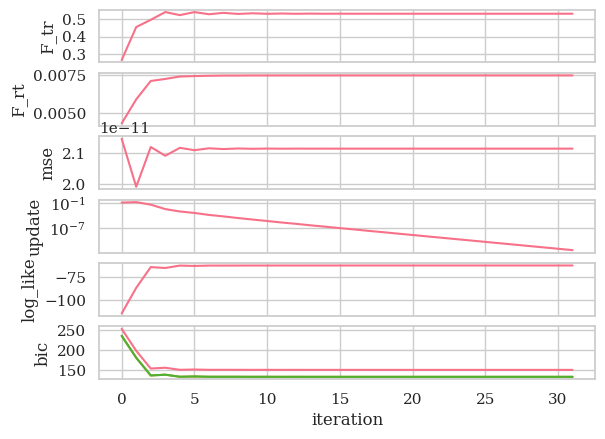

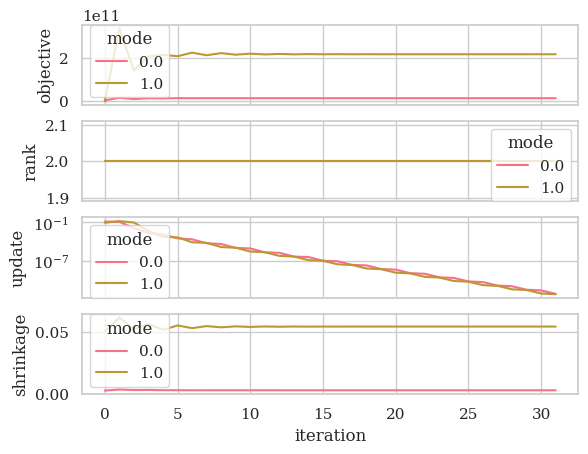

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(6,1, sharex=True)
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_tr', ax=axs[0])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_rt', ax=axs[1])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='mse', ax=axs[2])
    #axs[2].set(yscale="log")
    #axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='log_like', ax=axs[4])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='bic', ax=axs[5])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aic', ax=axs[5])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aicc', ax=axs[5])

    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='rank',hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='shrinkage',hue='mode', ax=axs[3])


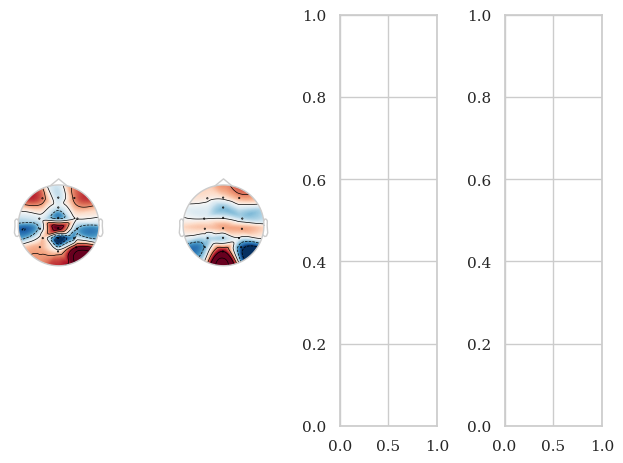

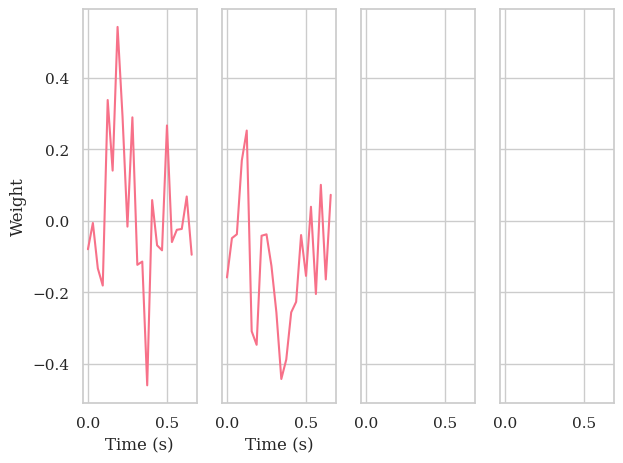

In [112]:

import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_(0)):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.weights_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


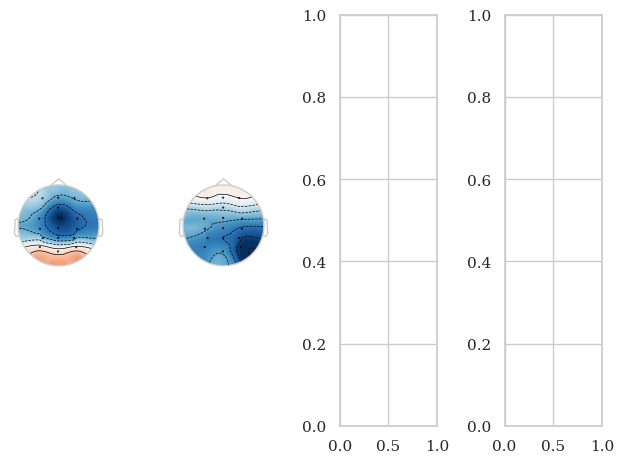

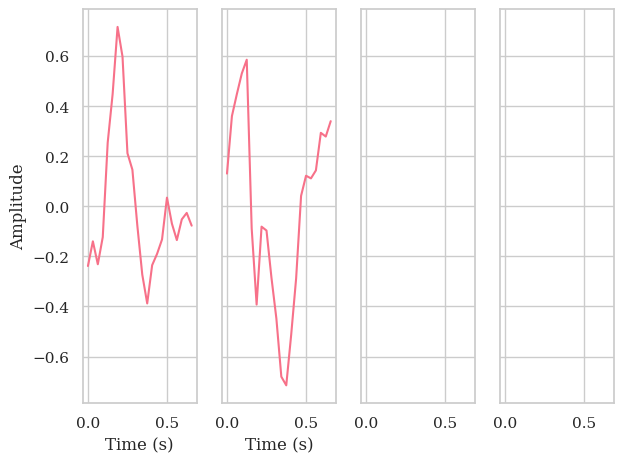

In [113]:

n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');


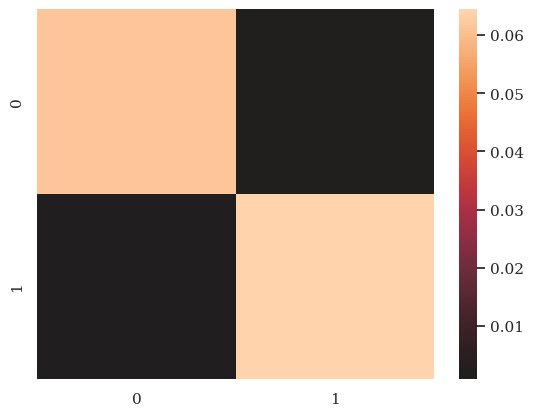

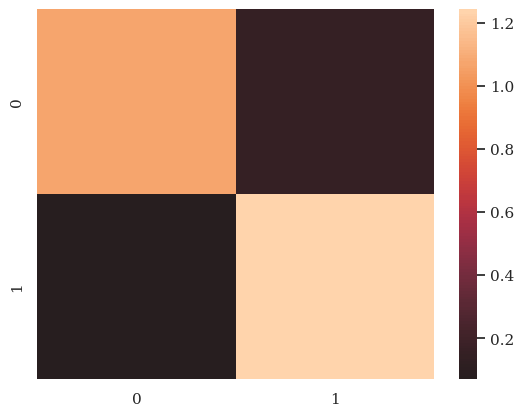

In [114]:
for k in range(2):
    sns.heatmap(tl.to_numpy(hoda.weights_[k].T@ hoda.aps_[k]), center=0)
    plt.show()


In [115]:
Xt = hoda.transform(X)

[[9.32356281e-01 1.47092863e-51]
 [5.23465649e-72 1.07011499e-05]]

[2.45011231e-20 6.68926465e-59]

[4.52766893e-29 2.00516471e-46]


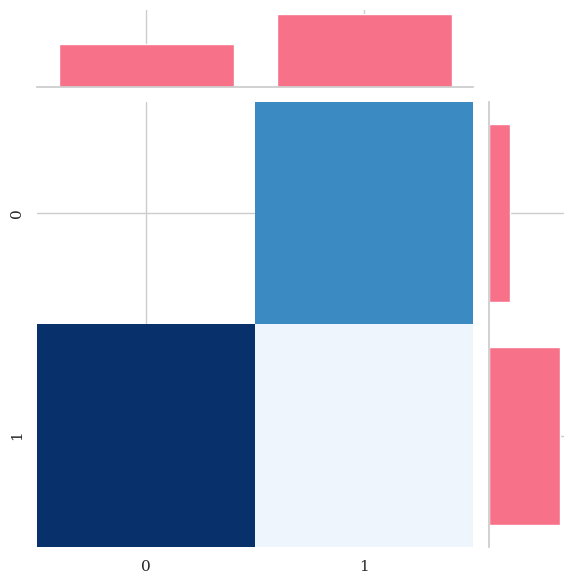

In [116]:
from hoda.hoda import f_multiway
from hoda.gpu_opt import combine_pvalues

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)

print(p)
print()
print(p_sp)
print()
print(p_tmp)

In [117]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(576, 4)

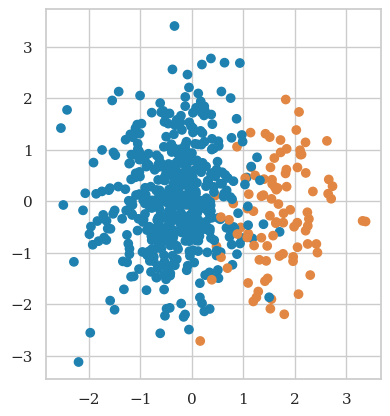

In [118]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

No projector specified for this dataset. Please consider the method self.add_proj.


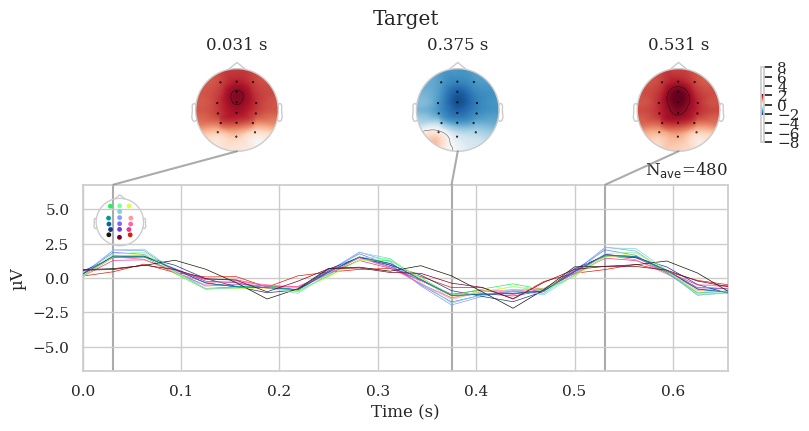

No projector specified for this dataset. Please consider the method self.add_proj.


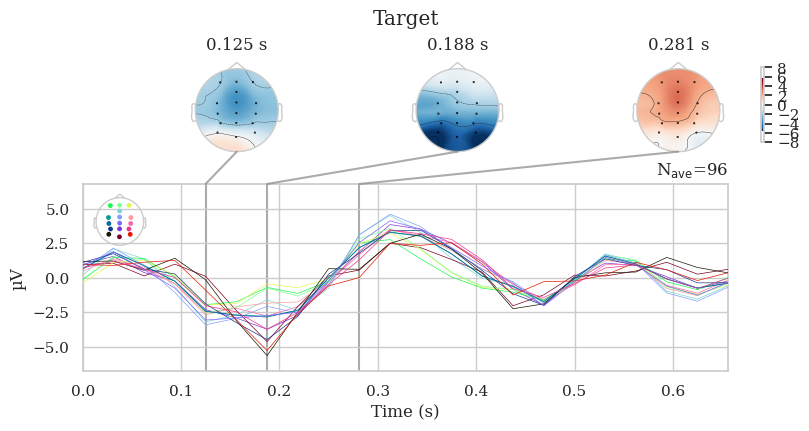

In [119]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_2584/286715887.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))


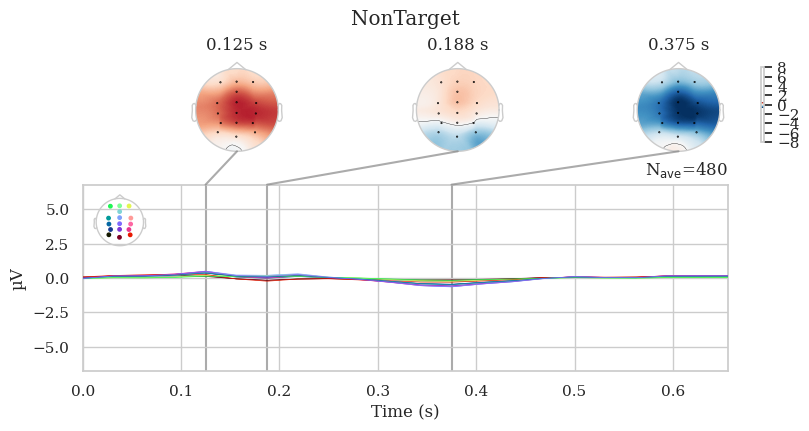

No projector specified for this dataset. Please consider the method self.add_proj.


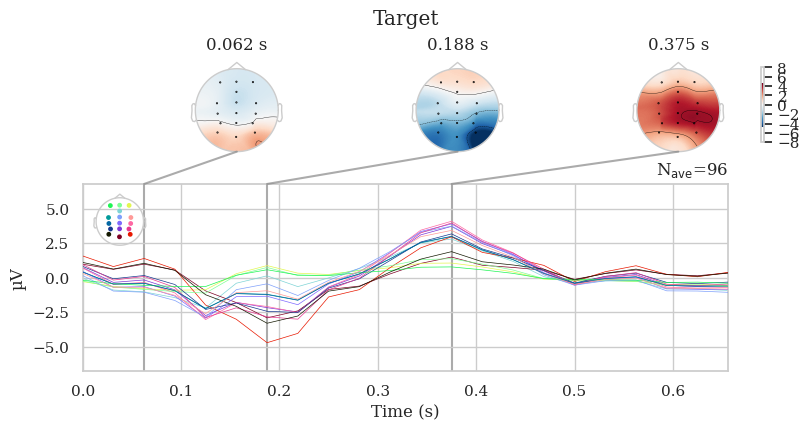

In [120]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls,**joint_args)
    else:
        evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


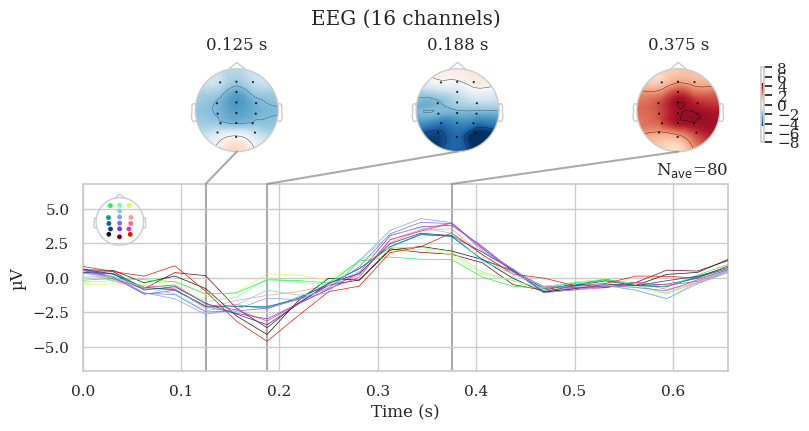

No projector specified for this dataset. Please consider the method self.add_proj.


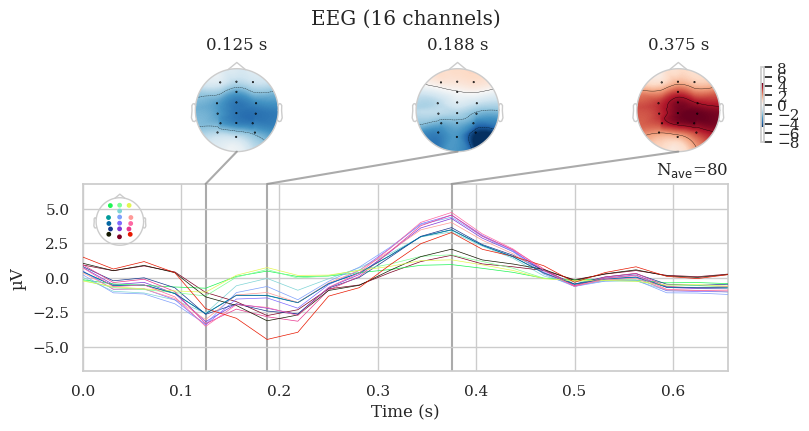

In [121]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


No projector specified for this dataset. Please consider the method self.add_proj.


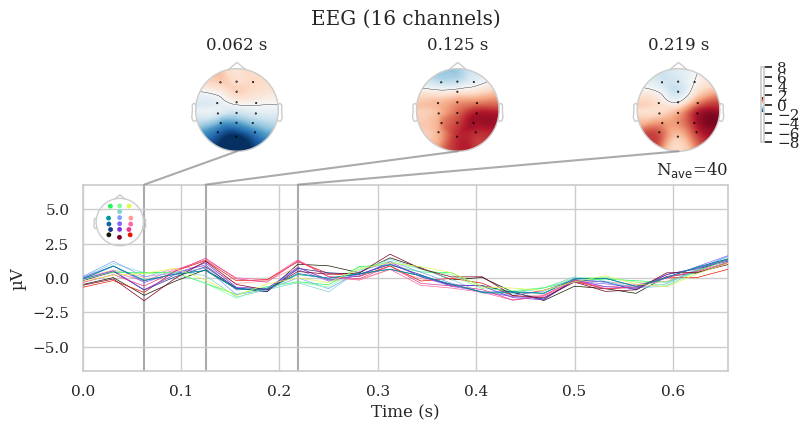

In [122]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)